<span style="font-size: 28px;">1. Importar librerías</span>

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

print("LibrerÃ­as cargadas correctamente")

LibrerÃ­as cargadas correctamente


<span style="font-size: 28px;">2. Definir parámetros de la estrategia</span>

In [2]:
ticker_bbva = "BBVA.MC"
ticker_san = "SAN.MC"

tickers = [ticker_bbva, ticker_san]

# Periodo ampliado a 20 años
end_date = None
start_date = (pd.Timestamp.today() - pd.DateOffset(years=20)).strftime("%Y-%m-%d")

# Ventanas móviles
trading_days = 252
hedge_window = 252   # 12 meses bursátiles para beta rolling
signal_window = 252  # 12 meses bursátiles para media/std del spread

# Reglas de trading
entry_z = 2.0
exit_z = 0.5

# Nueva regla: duración máxima de una operación
max_holding_months = 1
max_holding_offset = pd.DateOffset(months=max_holding_months)

# Costes aproximados
transaction_cost_bps = 5

print("Par analizado:")
print(f"Activo 1: {ticker_bbva}")
print(f"Activo 2: {ticker_san}")
print(f"Fecha inicial aproximada: {start_date}")
print(f"Ventana hedge ratio rolling: {hedge_window} días")
print(f"Ventana señales rolling: {signal_window} días")
print(f"Entrada: +/- {entry_z} desviaciones estándar")
print(f"Salida: +/- {exit_z} desviaciones estándar")
print(f"Duración máxima por operación: {max_holding_months} mes natural")

Par analizado:
Activo 1: BBVA.MC
Activo 2: SAN.MC
Fecha inicial aproximada: 2006-04-29
Ventana hedge ratio rolling: 252 días
Ventana señales rolling: 252 días
Entrada: +/- 2.0 desviaciones estándar
Salida: +/- 0.5 desviaciones estándar
Duración máxima por operación: 1 mes natural


<span style="font-size: 28px;">3. Descargar precios con yfinance</span>

In [3]:
download_kwargs = {
    "tickers": tickers,
    "start": start_date,
    "auto_adjust": True,
    "progress": False
}

if end_date is not None:
    download_kwargs["end"] = end_date

raw_data = yf.download(**download_kwargs)

prices = raw_data["Close"].copy()

prices = prices.rename(columns={
    ticker_bbva: "BBVA",
    ticker_san: "SAN"
})

prices = prices.dropna()

prices.head()

Ticker,BBVA,SAN
Date,,
2006-05-02,5.962997,3.644412
2006-05-03,5.888248,3.608566
2006-05-04,5.854270,3.596617
2006-05-05,5.905235,3.632463
2006-05-08,5.939213,3.641424


<span style="font-size: 28px;">4. Revisar datos descargados</span>

In [4]:
print("NÃºmero de observaciones:", len(prices))
print("Fecha inicial:", prices.index.min())
print("Fecha final:", prices.index.max())
print("Columnas:", prices.columns.tolist())

prices.tail()

NÃºmero de observaciones: 5110
Fecha inicial: 2006-05-02 00:00:00
Fecha final: 2026-04-29 00:00:00
Columnas: ['BBVA', 'SAN']


Ticker,BBVA,SAN
Date,,
2026-04-23,18.660000,10.326
2026-04-24,18.580000,10.198
2026-04-27,18.715000,10.276
2026-04-28,18.780001,10.366
2026-04-29,18.475000,10.474


<span style="font-size: 28px;">5. Graficar precios normalizados</span>

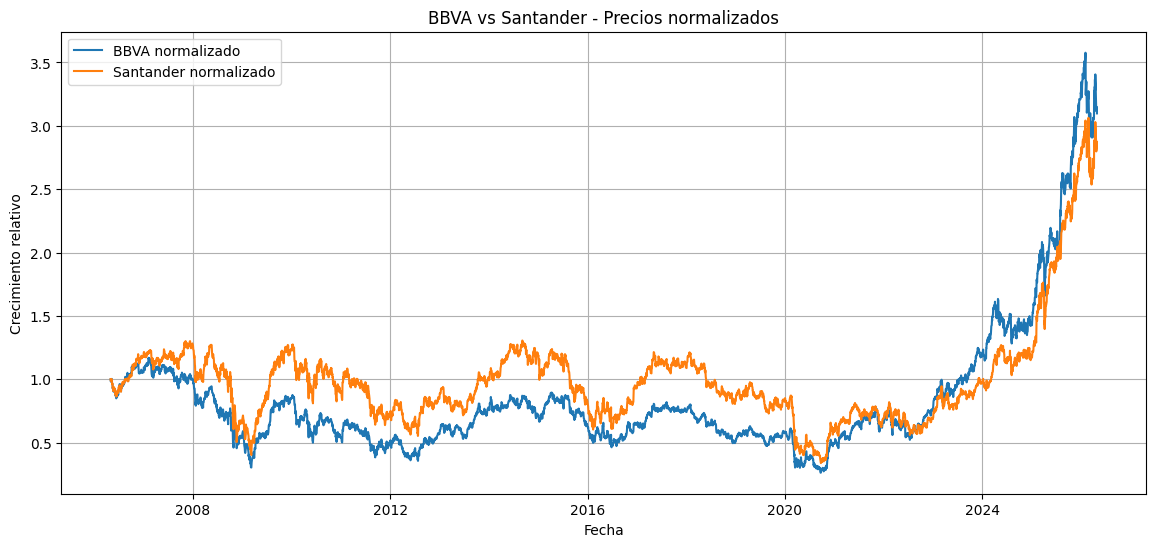

In [5]:
normalized_prices = prices / prices.iloc[0]

plt.figure(figsize=(14, 6))

plt.plot(normalized_prices.index, normalized_prices["BBVA"], label="BBVA normalizado")
plt.plot(normalized_prices.index, normalized_prices["SAN"], label="Santander normalizado")

plt.title("BBVA vs Santander - Precios normalizados")
plt.xlabel("Fecha")
plt.ylabel("Crecimiento relativo")
plt.legend()
plt.grid(True)
plt.show()

<span style="font-size: 28px;">6. Calcular precios logarítmicos</span>

In [6]:
log_prices = np.log(prices)

log_prices.head()

Ticker,BBVA,SAN
Date,,
2006-05-02,1.785573,1.293195
2006-05-03,1.772959,1.283310
2006-05-04,1.767171,1.279994
2006-05-05,1.775839,1.289911
2006-05-08,1.781577,1.292375


<span style="font-size: 28px;">7. Calcular hedge ratio</span>

In [7]:
x = log_prices["SAN"]
y = log_prices["BBVA"]

# Para evitar look-ahead bias, estimamos alpha y beta usando datos hasta ayer
x_lagged = x.shift(1)
y_lagged = y.shift(1)

rolling_cov = y_lagged.rolling(window=hedge_window).cov(x_lagged)
rolling_var = x_lagged.rolling(window=hedge_window).var()

rolling_beta = rolling_cov / rolling_var

rolling_alpha = (
    y_lagged.rolling(window=hedge_window).mean()
    - rolling_beta * x_lagged.rolling(window=hedge_window).mean()
)

hedge_data = pd.DataFrame({
    "Log_BBVA": y,
    "Log_SAN": x,
    "Rolling_Alpha": rolling_alpha,
    "Rolling_Beta": rolling_beta
})

hedge_data.tail()

,Log_BBVA,Log_SAN,Rolling_Alpha,Rolling_Beta
Date,,,,
2026-04-23,2.926382,2.334665,0.430549,1.086843
2026-04-24,2.922086,2.322192,0.428221,1.087766
2026-04-27,2.929325,2.329811,0.427427,1.088032
2026-04-28,2.932793,2.338531,0.423879,1.089536
2026-04-29,2.916418,2.348896,0.422559,1.090019


<span style="font-size: 28px;">8. Construir el spread</span>

In [8]:
spread = (
    hedge_data["Log_BBVA"]
    - (
        hedge_data["Rolling_Alpha"]
        + hedge_data["Rolling_Beta"] * hedge_data["Log_SAN"]
    )
)

spread.name = "Rolling_Spread"

spread_data = pd.DataFrame({
    "BBVA": prices["BBVA"],
    "SAN": prices["SAN"],
    "Log_BBVA": hedge_data["Log_BBVA"],
    "Log_SAN": hedge_data["Log_SAN"],
    "Rolling_Alpha": hedge_data["Rolling_Alpha"],
    "Rolling_Beta": hedge_data["Rolling_Beta"],
    "Spread": spread
})

spread_data.tail()

,BBVA,SAN,Log_BBVA,Log_SAN,Rolling_Alpha,Rolling_Beta,Spread
Date,,,,,,,
2026-04-23,18.660000,10.326,2.926382,2.334665,0.430549,1.086843,-0.041581
2026-04-24,18.580000,10.198,2.922086,2.322192,0.428221,1.087766,-0.032136
2026-04-27,18.715000,10.276,2.929325,2.329811,0.427427,1.088032,-0.033011
2026-04-28,18.780001,10.366,2.932793,2.338531,0.423879,1.089536,-0.039000
2026-04-29,18.475000,10.474,2.916418,2.348896,0.422559,1.090019,-0.066482


<span style="font-size: 28px;">9. Graficar el spread</span>

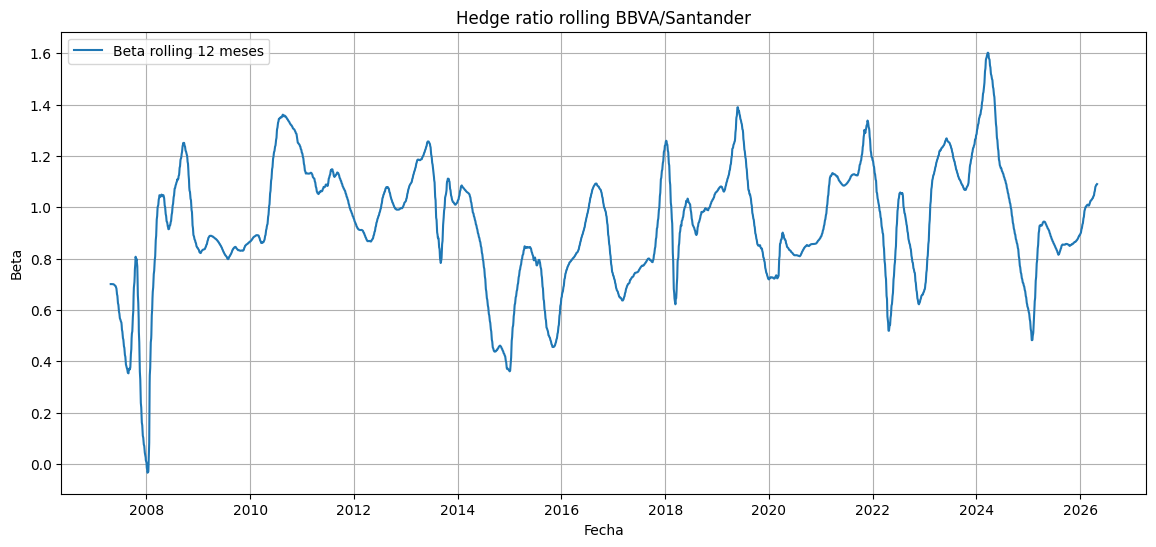

In [9]:
plt.figure(figsize=(14, 6))

plt.plot(
    spread_data.index,
    spread_data["Rolling_Beta"],
    label="Beta rolling 12 meses"
)

plt.title("Hedge ratio rolling BBVA/Santander")
plt.xlabel("Fecha")
plt.ylabel("Beta")
plt.legend()
plt.grid(True)
plt.show()

<span style="font-size: 28px;">10. Calibrar proceso Ornstein-Uhlenbeck sobre el spread</span>

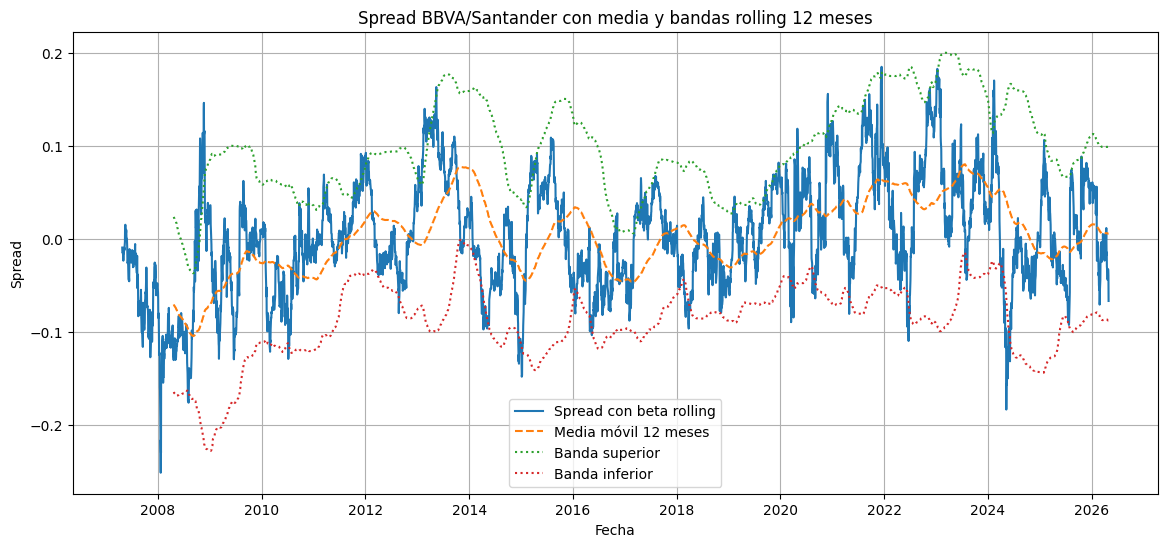

In [10]:
rolling_spread_mean = spread.rolling(window=signal_window).mean()
rolling_spread_std = spread.rolling(window=signal_window).std()

# Para señales reales, usaremos la media/std conocidas hasta ayer
rolling_spread_mean_signal = rolling_spread_mean.shift(1)
rolling_spread_std_signal = rolling_spread_std.shift(1)

upper_band = rolling_spread_mean_signal + entry_z * rolling_spread_std_signal
lower_band = rolling_spread_mean_signal - entry_z * rolling_spread_std_signal

plt.figure(figsize=(14, 6))

plt.plot(spread.index, spread, label="Spread con beta rolling")
plt.plot(
    rolling_spread_mean_signal.index,
    rolling_spread_mean_signal,
    linestyle="--",
    label="Media móvil 12 meses"
)
plt.plot(upper_band.index, upper_band, linestyle=":", label="Banda superior")
plt.plot(lower_band.index, lower_band, linestyle=":", label="Banda inferior")

plt.title("Spread BBVA/Santander con media y bandas rolling 12 meses")
plt.xlabel("Fecha")
plt.ylabel("Spread")
plt.legend()
plt.grid(True)
plt.show()

<span style="font-size: 28px;">11. Crear z-score basado en OU</span>

In [11]:
zscore = (
    spread - rolling_spread_mean_signal
) / rolling_spread_std_signal

zscore.name = "Rolling_ZScore"

signal_data = pd.DataFrame({
    "Spread": spread,
    "Rolling_Mean_12M": rolling_spread_mean_signal,
    "Rolling_Std_12M": rolling_spread_std_signal,
    "ZScore": zscore,
    "Rolling_Beta": spread_data["Rolling_Beta"],
    "Rolling_Alpha": spread_data["Rolling_Alpha"]
})

signal_data.tail()

,Spread,Rolling_Mean_12M,Rolling_Std_12M,ZScore,Rolling_Beta,Rolling_Alpha
Date,,,,,,
2026-04-23,-0.041581,0.005968,0.046595,-1.020461,1.086843,0.430549
2026-04-24,-0.032136,0.005913,0.046643,-0.815739,1.087766,0.428221
2026-04-27,-0.033011,0.005979,0.046578,-0.837098,1.088032,0.427427
2026-04-28,-0.039000,0.005979,0.046577,-0.965692,1.089536,0.423879
2026-04-29,-0.066482,0.005993,0.046564,-1.556467,1.090019,0.422559


<span style="font-size: 28px;">12. Graficar z-score</span>

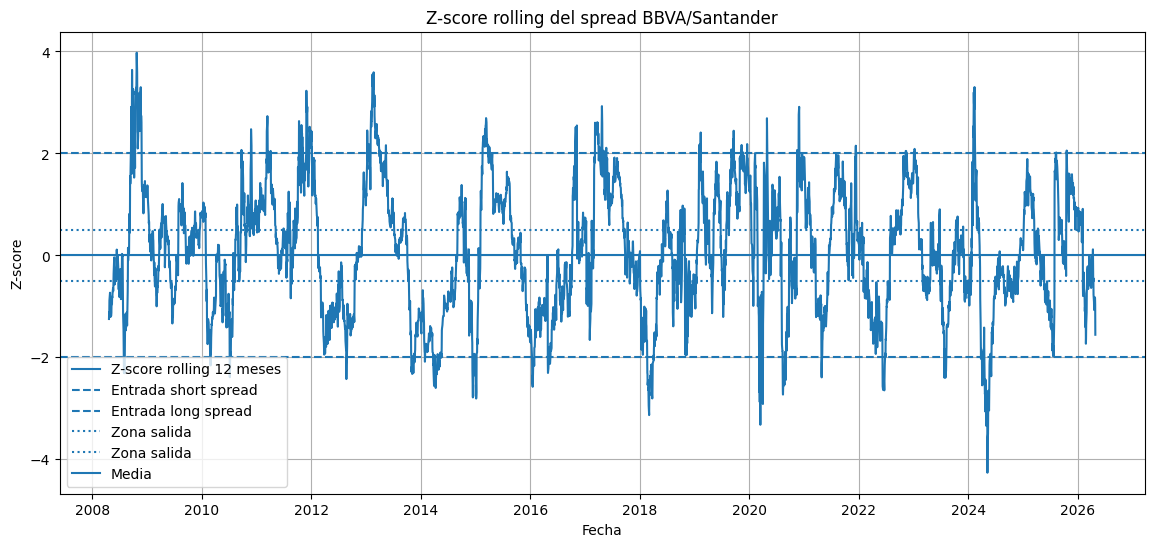

In [12]:
plt.figure(figsize=(14, 6))

plt.plot(zscore.index, zscore, label="Z-score rolling 12 meses")

plt.axhline(entry_z, linestyle="--", label="Entrada short spread")
plt.axhline(-entry_z, linestyle="--", label="Entrada long spread")
plt.axhline(exit_z, linestyle=":", label="Zona salida")
plt.axhline(-exit_z, linestyle=":", label="Zona salida")
plt.axhline(0, linestyle="-", label="Media")

plt.title("Z-score rolling del spread BBVA/Santander")
plt.xlabel("Fecha")
plt.ylabel("Z-score")
plt.legend()
plt.grid(True)
plt.show()

<span style="font-size: 28px;">13. Crear señales de trading</span>

In [13]:
strategy_data = pd.DataFrame(index=prices.index)

strategy_data["BBVA"] = prices["BBVA"]
strategy_data["SAN"] = prices["SAN"]
strategy_data["Spread"] = spread
strategy_data["Rolling_Mean_12M"] = rolling_spread_mean_signal
strategy_data["Rolling_Std_12M"] = rolling_spread_std_signal
strategy_data["ZScore"] = zscore
strategy_data["Alpha"] = spread_data["Rolling_Alpha"]
strategy_data["Beta"] = spread_data["Rolling_Beta"]

positions = []
events = []
entry_dates = []
holding_calendar_days = []

current_position = 0
current_entry_date = None

for date, z in strategy_data["ZScore"].items():
    event = ""

    # Si no hay z-score disponible, no tomamos posición
    if pd.isna(z):
        if current_position != 0:
            event = "Salida por datos insuficientes"

        current_position = 0
        current_entry_date = None

    else:
        # ------------------------------------------------------------
        # 1. Revisar primero si una posición abierta supera un mes natural
        # ------------------------------------------------------------
        if current_position != 0 and current_entry_date is not None:
            max_exit_date = current_entry_date + max_holding_offset

            if date >= max_exit_date:
                current_position = 0
                current_entry_date = None
                event = "Salida por tiempo maximo"

        # ------------------------------------------------------------
        # 2. Si no cerró por tiempo, revisar salida normal por reversión
        # ------------------------------------------------------------
        if event == "" and current_position == 1:
            # Long spread: cerramos cuando el z-score vuelve hacia la zona de salida
            if z >= -exit_z:
                current_position = 0
                current_entry_date = None
                event = "Salida por reversion"

        elif event == "" and current_position == -1:
            # Short spread: cerramos cuando el z-score vuelve hacia la zona de salida
            if z <= exit_z:
                current_position = 0
                current_entry_date = None
                event = "Salida por reversion"

        # ------------------------------------------------------------
        # 3. Si estamos fuera, revisar nuevas entradas
        # No reabrimos en el mismo día si acabamos de cerrar por tiempo o reversión
        # ------------------------------------------------------------
        if event == "" and current_position == 0:
            if z <= -entry_z:
                current_position = 1
                current_entry_date = date
                event = "Entrada long spread"

            elif z >= entry_z:
                current_position = -1
                current_entry_date = date
                event = "Entrada short spread"

    positions.append(current_position)
    events.append(event)

    if current_position != 0 and current_entry_date is not None:
        entry_dates.append(current_entry_date)
        holding_calendar_days.append((date - current_entry_date).days)
    else:
        entry_dates.append(pd.NaT)
        holding_calendar_days.append(0)

strategy_data["Signal"] = positions
strategy_data["Event"] = events
strategy_data["Entry_Date"] = entry_dates
strategy_data["Holding_Calendar_Days"] = holding_calendar_days

strategy_data[[
    "Spread",
    "ZScore",
    "Beta",
    "Signal",
    "Event",
    "Entry_Date",
    "Holding_Calendar_Days"
]].tail()

,Spread,ZScore,Beta,Signal,Event,Entry_Date,Holding_Calendar_Days
Date,,,,,,,
2026-04-23,-0.041581,-1.020461,1.086843,0,,NaT,0
2026-04-24,-0.032136,-0.815739,1.087766,0,,NaT,0
2026-04-27,-0.033011,-0.837098,1.088032,0,,NaT,0
2026-04-28,-0.039000,-0.965692,1.089536,0,,NaT,0
2026-04-29,-0.066482,-1.556467,1.090019,0,,NaT,0


<span style="font-size: 28px;">14. Evitar sesgo de anticipación</span>

In [14]:
strategy_data["Position"] = strategy_data["Signal"].shift(1).fillna(0)

strategy_data[["ZScore", "Signal", "Position"]].tail()

,ZScore,Signal,Position
Date,,,
2026-04-23,-1.020461,0,0.0
2026-04-24,-0.815739,0,0.0
2026-04-27,-0.837098,0,0.0
2026-04-28,-0.965692,0,0.0
2026-04-29,-1.556467,0,0.0


<span style="font-size: 28px;">15. Calcular retornos de la estrategia</span>

In [15]:
returns = prices.pct_change()

strategy_data["BBVA_Return"] = returns["BBVA"]
strategy_data["SAN_Return"] = returns["SAN"]

# La posición de hoy viene de la señal de ayer.
# Por consistencia, usamos también el beta conocido ayer.
strategy_data["Beta_Trade"] = strategy_data["Beta"].shift(1)

strategy_data["Spread_Return"] = (
    strategy_data["BBVA_Return"]
    - strategy_data["Beta_Trade"] * strategy_data["SAN_Return"]
)

strategy_data["Gross_Exposure"] = 1 + strategy_data["Beta_Trade"].abs()

strategy_data["Strategy_Gross_Return"] = (
    strategy_data["Position"]
    * strategy_data["Spread_Return"]
    / strategy_data["Gross_Exposure"]
)

# Cambios de posición: 0 a 1, 1 a 0, 1 a -1, etc.
strategy_data["Trade_Size"] = strategy_data["Position"].diff().abs().fillna(0)

cost_rate = transaction_cost_bps / 10000

strategy_data["Transaction_Cost"] = strategy_data["Trade_Size"] * cost_rate

strategy_data["Strategy_Net_Return"] = (
    strategy_data["Strategy_Gross_Return"]
    - strategy_data["Transaction_Cost"]
)

strategy_data = strategy_data.dropna()

strategy_data[[
    "Position",
    "Beta_Trade",
    "BBVA_Return",
    "SAN_Return",
    "Spread_Return",
    "Gross_Exposure",
    "Strategy_Gross_Return",
    "Transaction_Cost",
    "Strategy_Net_Return"
]].tail()

,Position,Beta_Trade,BBVA_Return,SAN_Return,Spread_Return,Gross_Exposure,Strategy_Gross_Return,Transaction_Cost,Strategy_Net_Return
Date,,,,,,,,,
2025-11-13,-1.0,0.858232,-0.001322,-0.001464,-0.000066,1.858232,0.000036,0.0,0.000036
2025-11-14,-1.0,0.859386,-0.026218,-0.027120,-0.002911,1.859386,0.001566,0.0,0.001566
2025-11-17,-1.0,0.860435,-0.014958,-0.020558,0.002731,1.860435,-0.001468,0.0,-0.001468
2025-11-18,-1.0,0.861269,-0.028161,-0.035934,0.002788,1.861269,-0.001498,0.0,-0.001498
2025-11-19,-1.0,0.861942,0.009091,0.016756,-0.005352,1.861942,0.002874,0.0,0.002874


<span style="font-size: 28px;">16. Crear benchmark</span>

In [16]:
strategy_data["Benchmark_Return"] = (
    0.5 * strategy_data["BBVA_Return"] + 0.5 * strategy_data["SAN_Return"]
)

strategy_data["Strategy_Cumulative"] = (
    1 + strategy_data["Strategy_Net_Return"]
).cumprod()

strategy_data["Benchmark_Cumulative"] = (
    1 + strategy_data["Benchmark_Return"]
).cumprod()

strategy_data[["Strategy_Cumulative", "Benchmark_Cumulative"]].tail()

,Strategy_Cumulative,Benchmark_Cumulative
Date,,
2025-11-13,1.128420,1.152940
2025-11-14,1.130187,1.122192
2025-11-17,1.128528,1.102265
2025-11-18,1.126838,1.066939
2025-11-19,1.130077,1.080728


<span style="font-size: 28px;">17. Graficar estrategia vs benchmark</span>

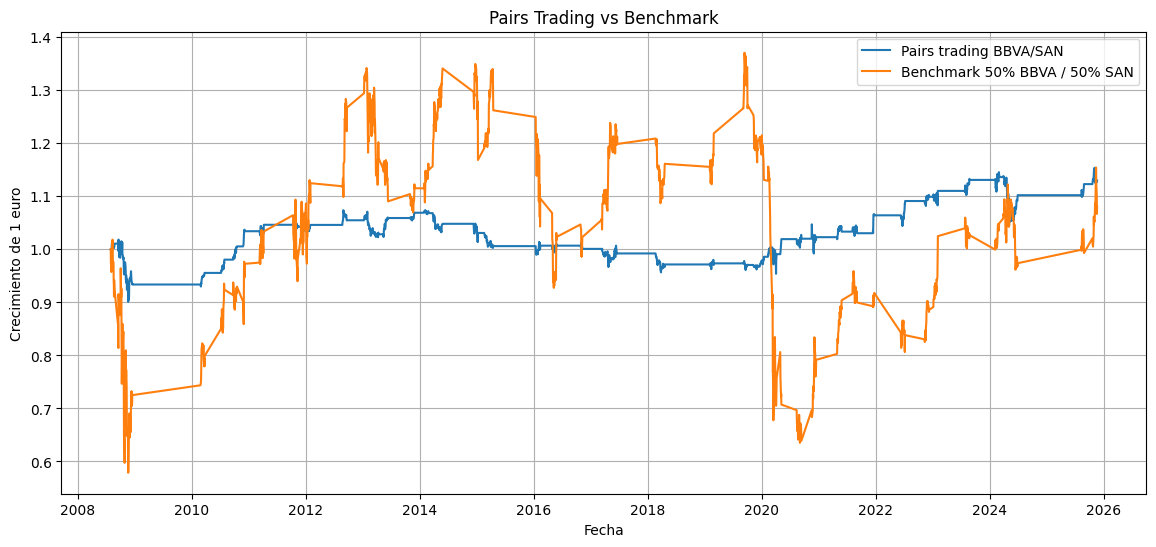

In [17]:
plt.figure(figsize=(14, 6))

plt.plot(
    strategy_data.index,
    strategy_data["Strategy_Cumulative"],
    label="Pairs trading BBVA/SAN"
)

plt.plot(
    strategy_data.index,
    strategy_data["Benchmark_Cumulative"],
    label="Benchmark 50% BBVA / 50% SAN"
)

plt.title("Pairs Trading vs Benchmark")
plt.xlabel("Fecha")
plt.ylabel("Crecimiento de 1 euro")
plt.legend()
plt.grid(True)
plt.show()

<span style="font-size: 28px;">18. Graficar señales sobre el z-score</span>

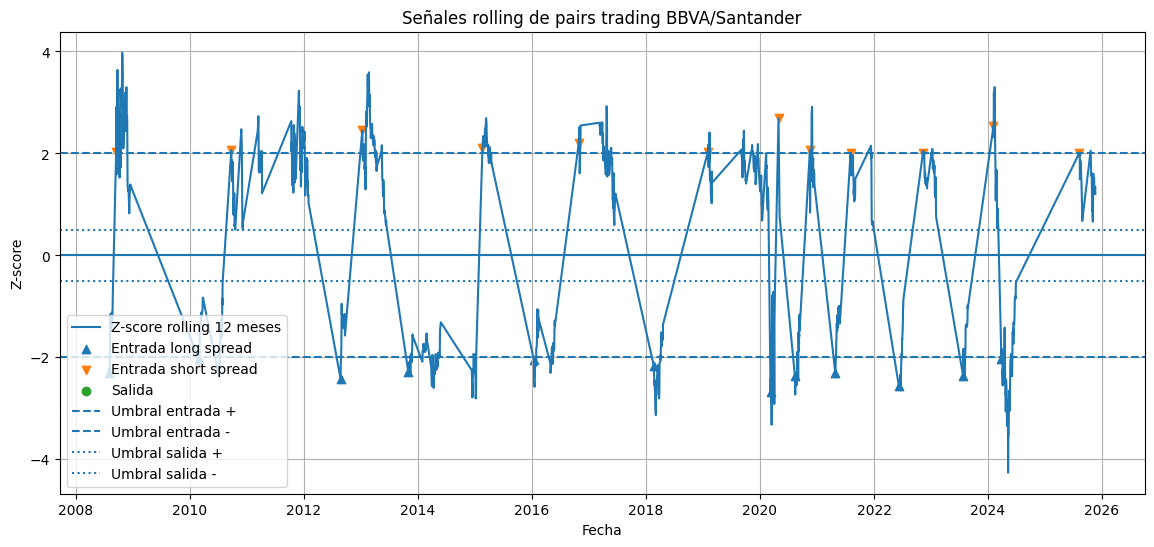

In [18]:
long_entries = strategy_data[
    (strategy_data["Signal"] == 1) & (strategy_data["Signal"].shift(1) != 1)
]

short_entries = strategy_data[
    (strategy_data["Signal"] == -1) & (strategy_data["Signal"].shift(1) != -1)
]

exits = strategy_data[
    (strategy_data["Signal"] == 0) & (strategy_data["Signal"].shift(1) != 0)
]

plt.figure(figsize=(14, 6))

plt.plot(strategy_data.index, strategy_data["ZScore"], label="Z-score rolling 12 meses")

plt.scatter(
    long_entries.index,
    long_entries["ZScore"],
    marker="^",
    label="Entrada long spread"
)

plt.scatter(
    short_entries.index,
    short_entries["ZScore"],
    marker="v",
    label="Entrada short spread"
)

plt.scatter(
    exits.index,
    exits["ZScore"],
    marker="o",
    label="Salida"
)

plt.axhline(entry_z, linestyle="--", label="Umbral entrada +")
plt.axhline(-entry_z, linestyle="--", label="Umbral entrada -")
plt.axhline(exit_z, linestyle=":", label="Umbral salida +")
plt.axhline(-exit_z, linestyle=":", label="Umbral salida -")
plt.axhline(0, linestyle="-")

plt.title("Señales rolling de pairs trading BBVA/Santander")
plt.xlabel("Fecha")
plt.ylabel("Z-score")
plt.legend()
plt.grid(True)
plt.show()

<span style="font-size: 28px;">19. Calcular métricas de rendimiento</span>

In [19]:
def annualized_return(cumulative_returns, periods_per_year=252):
    total_periods = len(cumulative_returns)
    if total_periods == 0:
        return np.nan
    return cumulative_returns.iloc[-1] ** (periods_per_year / total_periods) - 1


def annualized_volatility(daily_returns, periods_per_year=252):
    return daily_returns.std() * np.sqrt(periods_per_year)


def sharpe_ratio(daily_returns, periods_per_year=252):
    vol = annualized_volatility(daily_returns, periods_per_year)
    if vol == 0:
        return np.nan
    return (daily_returns.mean() * periods_per_year) / vol


def max_drawdown(cumulative_returns):
    running_max = cumulative_returns.cummax()
    drawdown = cumulative_returns / running_max - 1
    return drawdown.min()


# ------------------------------------------------------------
# 1. Construir retornos y duracion por operacion cerrada
# ------------------------------------------------------------

trade_records = []

in_trade = False
trade_start_date = None
trade_direction = 0
trade_growth = 1.0
days_in_trade = 0

for date, row in strategy_data.iterrows():
    position = row["Position"]
    daily_return = row["Strategy_Net_Return"]

    if pd.isna(daily_return):
        continue

    # Abrir operacion
    if not in_trade:
        if position != 0:
            in_trade = True
            trade_start_date = date
            trade_direction = position
            trade_growth = 1 + daily_return
            days_in_trade = 1

    # Operacion ya abierta
    else:
        # Mantener misma posicion
        if position == trade_direction:
            trade_growth *= 1 + daily_return
            days_in_trade += 1

        # Cerrar posicion
        elif position == 0:
            # Incluye el coste/retorno del dia de salida
            trade_growth *= 1 + daily_return

            trade_records.append({
                "Fecha entrada": trade_start_date,
                "Fecha salida": date,
                "Direccion": "Long spread" if trade_direction == 1 else "Short spread",
                "Dias en operacion": days_in_trade,
                "Retorno operacion": trade_growth - 1
            })

            in_trade = False
            trade_start_date = None
            trade_direction = 0
            trade_growth = 1.0
            days_in_trade = 0

        # Cambio directo de long a short o viceversa
        else:
            trade_growth *= 1 + daily_return

            trade_records.append({
                "Fecha entrada": trade_start_date,
                "Fecha salida": date,
                "Direccion": "Long spread" if trade_direction == 1 else "Short spread",
                "Dias en operacion": days_in_trade,
                "Retorno operacion": trade_growth - 1
            })

            in_trade = True
            trade_start_date = date
            trade_direction = position
            trade_growth = 1.0
            days_in_trade = 0


trade_log = pd.DataFrame(trade_records)

if len(trade_log) > 0:
    trade_returns = trade_log["Retorno operacion"]
    trade_durations = trade_log["Dias en operacion"]

    avg_return_per_trade = trade_returns.mean()
    std_return_per_trade = trade_returns.std(ddof=1)

    max_return_per_trade = trade_returns.max()
    min_return_per_trade = trade_returns.min()

    avg_days_per_trade = trade_durations.mean()
    std_days_per_trade = trade_durations.std(ddof=1)

    best_trade_idx = trade_returns.idxmax()
    worst_trade_idx = trade_returns.idxmin()

    best_trade_days = trade_log.loc[best_trade_idx, "Dias en operacion"]
    worst_trade_days = trade_log.loc[worst_trade_idx, "Dias en operacion"]

    number_of_closed_trades = len(trade_log)

else:
    avg_return_per_trade = np.nan
    std_return_per_trade = np.nan
    max_return_per_trade = np.nan
    min_return_per_trade = np.nan

    avg_days_per_trade = np.nan
    std_days_per_trade = np.nan
    best_trade_days = np.nan
    worst_trade_days = np.nan

    number_of_closed_trades = 0


# ------------------------------------------------------------
# 2. Metricas generales de estrategia y benchmark
# ------------------------------------------------------------

strategy_total_return = strategy_data["Strategy_Cumulative"].iloc[-1] - 1
benchmark_total_return = strategy_data["Benchmark_Cumulative"].iloc[-1] - 1

strategy_annual_return = annualized_return(strategy_data["Strategy_Cumulative"])
benchmark_annual_return = annualized_return(strategy_data["Benchmark_Cumulative"])

strategy_volatility = annualized_volatility(strategy_data["Strategy_Net_Return"])
benchmark_volatility = annualized_volatility(strategy_data["Benchmark_Return"])

strategy_sharpe = sharpe_ratio(strategy_data["Strategy_Net_Return"])
benchmark_sharpe = sharpe_ratio(strategy_data["Benchmark_Return"])

strategy_max_dd = max_drawdown(strategy_data["Strategy_Cumulative"])
benchmark_max_dd = max_drawdown(strategy_data["Benchmark_Cumulative"])


# ------------------------------------------------------------
# 3. Tabla de metricas
# ------------------------------------------------------------

metrics = pd.DataFrame({
    "Pairs Trading Rolling": [
        strategy_total_return,
        strategy_annual_return,
        strategy_volatility,
        strategy_sharpe,
        strategy_max_dd,
        number_of_closed_trades,
        avg_return_per_trade,
        std_return_per_trade,
        max_return_per_trade,
        min_return_per_trade,
        avg_days_per_trade,
        std_days_per_trade,
        best_trade_days,
        worst_trade_days
    ],
    "Benchmark 50/50": [
        benchmark_total_return,
        benchmark_annual_return,
        benchmark_volatility,
        benchmark_sharpe,
        benchmark_max_dd,
        np.nan,
        np.nan,
        np.nan,
        np.nan,
        np.nan,
        np.nan,
        np.nan,
        np.nan,
        np.nan
    ]
}, index=[
    "Retorno total",
    "Retorno anualizado",
    "Volatilidad anualizada",
    "Sharpe simple",
    "Maximo drawdown",
    "Numero de operaciones cerradas",
    "Retorno promedio por operacion",
    "Desviacion tipica por operacion",
    "Mejor operacion",
    "Peor operacion",
    "Dias promedio por operacion",
    "Desviacion tipica dias por operacion",
    "Duracion mejor operacion",
    "Duracion peor operacion"
])

metrics

,Pairs Trading Rolling,Benchmark 50/50
Retorno total,0.130077,0.080728
Retorno anualizado,0.029136,0.018400
Volatilidad anualizada,0.088868,0.386724
Sharpe simple,0.367600,0.241258
Maximo drawdown,-0.115205,-0.536885
Numero de operaciones cerradas,53.000000,NaN
Retorno promedio por operacion,0.002356,NaN
Desviacion tipica por operacion,0.018168,NaN
Mejor operacion,0.032804,NaN
Peor operacion,-0.059812,NaN


<span style="font-size: 28px;">20. Formatear métricas</span>

In [20]:
display_metrics = metrics.copy().astype(object)

for row in display_metrics.index:
    row_lower = row.lower()

    if "numero de operaciones" in row_lower:
        display_metrics.loc[row] = display_metrics.loc[row].map(
            lambda x: "" if pd.isna(x) else f"{int(x)}"
        )

    elif (
        "dias promedio" in row_lower
        or "desviacion tipica dias" in row_lower
    ):
        display_metrics.loc[row] = display_metrics.loc[row].map(
            lambda x: "" if pd.isna(x) else f"{x:.1f} dias"
        )

    elif (
        "duracion mejor" in row_lower
        or "duracion peor" in row_lower
    ):
        display_metrics.loc[row] = display_metrics.loc[row].map(
            lambda x: "" if pd.isna(x) else f"{int(x)} dias"
        )

    elif "sharpe" in row_lower:
        display_metrics.loc[row] = display_metrics.loc[row].map(
            lambda x: "" if pd.isna(x) else f"{x:.2f}"
        )

    elif (
        "retorno" in row_lower
        or "volatilidad" in row_lower
        or "drawdown" in row_lower
        or "mejor operacion" in row_lower
        or "peor operacion" in row_lower
        or "desviacion tipica por operacion" in row_lower
    ):
        display_metrics.loc[row] = display_metrics.loc[row].map(
            lambda x: "" if pd.isna(x) else f"{x:.2%}"
        )

display_metrics

,Pairs Trading Rolling,Benchmark 50/50
Retorno total,13.01%,8.07%
Retorno anualizado,2.91%,1.84%
Volatilidad anualizada,8.89%,38.67%
Sharpe simple,0.37,0.24
Maximo drawdown,-11.52%,-53.69%
Numero de operaciones cerradas,53,
Retorno promedio por operacion,0.24%,
Desviacion tipica por operacion,1.82%,
Mejor operacion,3.28%,
Peor operacion,-5.98%,


<span style="font-size: 28px;">21. Resumen ejecutivo del backtest</span>

In [21]:
print("RESUMEN EJECUTIVO")
print("-" * 70)

print("Modelo: Pairs Trading BBVA/Santander con hedge ratio rolling")
print(f"Par: {ticker_bbva} / {ticker_san}")
print(f"Periodo aproximado: últimos 20 años")
print(f"Fecha inicial efectiva del backtest: {strategy_data.index.min().date()}")
print(f"Fecha final del backtest: {strategy_data.index.max().date()}")

print("-" * 70)

print(f"Ventana beta rolling: {hedge_window} días bursátiles")
print(f"Ventana media/std rolling: {signal_window} días bursátiles")
print(f"Entrada: +/- {entry_z} desviaciones estándar")
print(f"Salida: +/- {exit_z} desviaciones estándar")
print(f"Coste por cambio de posición: {transaction_cost_bps} bps")

print("-" * 70)

print(f"Beta rolling promedio: {strategy_data['Beta'].mean():.4f}")
print(f"Beta rolling mínimo: {strategy_data['Beta'].min():.4f}")
print(f"Beta rolling máximo: {strategy_data['Beta'].max():.4f}")

print("-" * 70)

print(f"Retorno total estrategia: {strategy_total_return:.2%}")
print(f"Retorno total benchmark: {benchmark_total_return:.2%}")

print(f"Retorno anualizado estrategia: {strategy_annual_return:.2%}")
print(f"Retorno anualizado benchmark: {benchmark_annual_return:.2%}")

print(f"Volatilidad estrategia: {strategy_volatility:.2%}")
print(f"Volatilidad benchmark: {benchmark_volatility:.2%}")

print(f"Sharpe estrategia: {strategy_sharpe:.2f}")
print(f"Sharpe benchmark: {benchmark_sharpe:.2f}")

print(f"Máximo drawdown estrategia: {strategy_max_dd:.2%}")
print(f"Máximo drawdown benchmark: {benchmark_max_dd:.2%}")

print(f"Número aproximado de trades: {number_of_trades}")

RESUMEN EJECUTIVO
----------------------------------------------------------------------
Modelo: Pairs Trading BBVA/Santander con hedge ratio rolling
Par: BBVA.MC / SAN.MC
Periodo aproximado: últimos 20 años
Fecha inicial efectiva del backtest: 2008-07-31
Fecha final del backtest: 2025-11-19
----------------------------------------------------------------------
Ventana beta rolling: 252 días bursátiles
Ventana media/std rolling: 252 días bursátiles
Entrada: +/- 2.0 desviaciones estándar
Salida: +/- 0.5 desviaciones estándar
Coste por cambio de posición: 5 bps
----------------------------------------------------------------------
Beta rolling promedio: 0.9797
Beta rolling mínimo: 0.3607
Beta rolling máximo: 1.5888
----------------------------------------------------------------------
Retorno total estrategia: 13.01%
Retorno total benchmark: 8.07%
Retorno anualizado estrategia: 2.91%
Retorno anualizado benchmark: 1.84%
Volatilidad estrategia: 8.89%
Volatilidad benchmark: 38.67%
Sharpe es

NameError: name 'number_of_trades' is not defined